In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("../dataset/salary_dataset.csv") #[..] use to go back current folder and look to given folder path

In [4]:
df.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [5]:
df.shape

(1000, 7)

In [6]:
df.columns

Index(['Education', 'Experience', 'Location', 'Job_Title', 'Age', 'Gender',
       'Salary'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Education   1000 non-null   object 
 1   Experience  1000 non-null   int64  
 2   Location    1000 non-null   object 
 3   Job_Title   1000 non-null   object 
 4   Age         1000 non-null   int64  
 5   Gender      1000 non-null   object 
 6   Salary      1000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


In [8]:
df.describe()

,Experience,Age,Salary
count,1000.000000,1000.000000,1000.000000
mean,14.771000,42.377000,105558.404239
std,8.341111,13.609412,28256.972075
min,1.000000,20.000000,33510.510669
25%,7.000000,30.000000,85032.141517
50%,15.000000,43.000000,104314.518315
75%,22.000000,55.000000,126804.047524
max,29.000000,64.000000,193016.602150


In [9]:
df.isnull().sum()

Education     0
Experience    0
Location      0
Job_Title     0
Age           0
Gender        0
Salary        0
dtype: int64

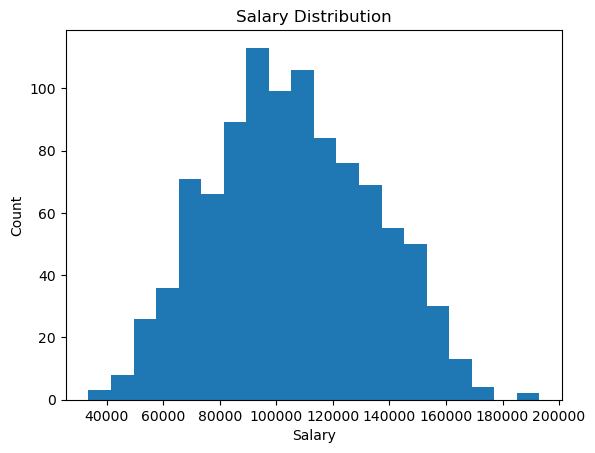

In [10]:
import matplotlib.pyplot as plt

plt.hist(df['Salary'], bins=20)
plt.xlabel('Salary')
plt.ylabel('Count')
plt.title('Salary Distribution')
plt.show()

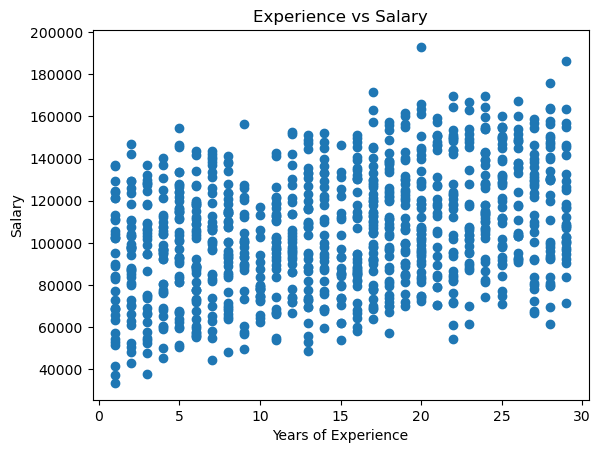

In [11]:
plt.scatter(df['Experience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

Correlation Between Numerical Columns

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.corr()

,Experience,Age,Salary
Experience,1.000000,0.044296,0.341918
Age,0.044296,1.000000,-0.053174
Salary,0.341918,-0.053174,1.000000


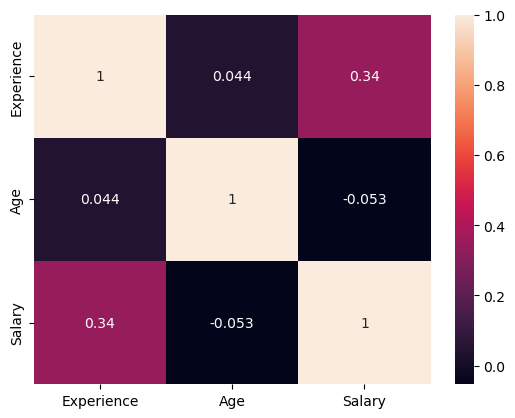

In [13]:
import seaborn as sns

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

Separate Features and Target

In [14]:
X = df.drop("Salary", axis=1)

y = df["Salary"]

In [16]:
print(X.head())


     Education  Experience  Location Job_Title  Age  Gender
0  High School           8     Urban   Manager   63    Male
1          PhD          11  Suburban  Director   59    Male
2     Bachelor          28  Suburban   Manager   61  Female
3  High School          29     Rural  Director   45    Male
4          PhD          25     Urban   Analyst   26  Female


In [17]:
print(y.head())

0     84620.053665
1    142591.255894
2     97800.255404
3     96834.671282
4    132157.786175
Name: Salary, dtype: float64


Identify Categorical Columns

In [18]:
X.select_dtypes(include="object").columns

Index(['Education', 'Location', 'Job_Title', 'Gender'], dtype='object')

In [19]:
X = pd.get_dummies(X, drop_first=True)

In [20]:
X.head()

,Experience,Age,Education_High School,Education_Master,Education_PhD,Location_Suburban,Location_Urban,Job_Title_Director,Job_Title_Engineer,Job_Title_Manager,Gender_Male
0,8,63,True,False,False,False,True,False,False,True,True
1,11,59,False,False,True,True,False,True,False,False,True
2,28,61,False,False,False,True,False,False,False,True,False
3,29,45,True,False,False,False,False,True,False,False,True
4,25,26,False,False,True,False,True,False,False,False,False


In [21]:
X.shape

(1000, 11)

In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Experience             1000 non-null   int64
 1   Age                    1000 non-null   int64
 2   Education_High School  1000 non-null   bool 
 3   Education_Master       1000 non-null   bool 
 4   Education_PhD          1000 non-null   bool 
 5   Location_Suburban      1000 non-null   bool 
 6   Location_Urban         1000 non-null   bool 
 7   Job_Title_Director     1000 non-null   bool 
 8   Job_Title_Engineer     1000 non-null   bool 
 9   Job_Title_Manager      1000 non-null   bool 
 10  Gender_Male            1000 non-null   bool 
dtypes: bool(9), int64(2)
memory usage: 24.5 KB


Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 11)
X_test: (200, 11)
y_train: (800,)
y_test: (200,)


Train the Model

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Make Predictions

In [26]:
y_pred = model.predict(X_test)

In [36]:
sample = X_test.iloc[[0]]  #check first person data and compare actual and pridicated value

prediction = model.predict(sample)

print("Predicted Salary:", prediction[0])

print("Actual Salary:", y_test.iloc[0])

Predicted Salary: 80980.43421260815
Actual Salary: 86677.84010920297


In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [29]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 8157.898478643179
MSE: 105996277.66096891
R2 Score: 0.8701863681609698


In [31]:
df.columns

Index(['Education', 'Experience', 'Location', 'Job_Title', 'Age', 'Gender',
       'Salary'],
      dtype='object')

Understand What the Model Learned

In [39]:
#this show that which feature affect the salay most
coefficients = pd.DataFrame({      
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
4,Education_PhD,40306.356922
7,Job_Title_Director,25106.575031
3,Education_Master,21105.767850
9,Job_Title_Manager,15284.961081
6,Location_Urban,9920.736221
5,Location_Suburban,4839.288704
8,Job_Title_Engineer,3979.180091
0,Experience,1002.178135
10,Gender_Male,503.422040
1,Age,10.004773


In [38]:
coefficients.sort_values(by='Coefficient').head(10)

,Feature,Coefficient
2,Education_High School,-18194.081071
1,Age,10.004773
10,Gender_Male,503.422040
0,Experience,1002.178135
8,Job_Title_Engineer,3979.180091
5,Location_Suburban,4839.288704
6,Location_Urban,9920.736221
9,Job_Title_Manager,15284.961081
3,Education_Master,21105.767850
7,Job_Title_Director,25106.575031


Save the Model

In [41]:
import joblib

joblib.dump(model, "../model/salary_model.pkl")

['../model/salary_model.pkl']

Because you used One-Hot Encoding, we must save the column structure.

In [43]:
joblib.dump(X.columns.tolist(), "../model/model_columns.pkl")

['../model/model_columns.pkl']